# Rain in Australia -- Next-Day Rainfall Prediction

A binary classification model predicting `RainTomorrow` (will it rain tomorrow, yes/no) from
today's weather observations, using the real "Rain in Australia" dataset: 145,460 daily
observations from 49 Australian weather stations (2007-2017), originally from the Australian
Bureau of Meteorology (via the `rattle` R package's `weatherAUS` dataset).

Separate sub-project from `../amazon-sales-analysis/` -- this one is a genuine supervised ML
pipeline (data cleaning -> feature engineering -> train/test split -> model -> evaluation), not
EDA/BI dashboarding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
)

RANDOM_STATE = 42

## 1. Load and inspect

In [2]:
df = pd.read_csv("data/weatherAUS.csv")
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

145,460 rows, 23 columns


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct[missing_pct > 0]

Sunshine         48.0
Evaporation      43.2
Cloud3pm         40.8
Cloud9am         38.4
Pressure9am      10.4
Pressure3pm      10.3
WindDir9am        7.3
WindGustSpeed     7.1
WindGustDir       7.1
Humidity3pm       3.1
WindDir3pm        2.9
Temp3pm           2.5
Rainfall          2.2
RainTomorrow      2.2
RainToday         2.2
WindSpeed3pm      2.1
Humidity9am       1.8
WindSpeed9am      1.2
Temp9am           1.2
MinTemp           1.0
MaxTemp           0.9
dtype: float64

## 2. Clean

- Drop rows with a missing target -- can't train or evaluate on those (2.2% of rows).
- Drop the four columns with >35% missing (`Sunshine`, `Evaporation`, `Cloud9am`, `Cloud3pm`):
  imputing that much of a column would mostly be inventing data, not filling gaps.
- Impute the remaining, much smaller gaps: median for numeric columns, mode for categorical.

In [4]:
df = df.dropna(subset=["RainTomorrow"])
print(f"{df.shape[0]:,} rows after dropping missing-target rows")

high_missing_cols = df.columns[df.isna().mean() > 0.35].tolist()
print("dropping (>35% missing):", high_missing_cols)
df = df.drop(columns=high_missing_cols)

142,193 rows after dropping missing-target rows
dropping (>35% missing): ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']


## 3. Feature engineering

In [5]:
target = df["RainTomorrow"].map({"No": 0, "Yes": 1})
print("Class balance:")
print(target.value_counts(normalize=True).rename("fraction"))

Class balance:
RainTomorrow
0    0.775819
1    0.224181
Name: fraction, dtype: float64


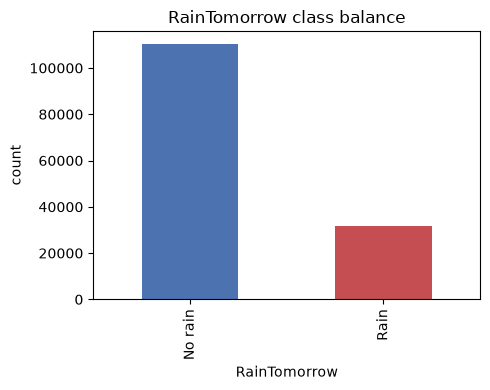

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
target.value_counts().rename({0: "No rain", 1: "Rain"}).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("count")
ax.set_title("RainTomorrow class balance")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=120)
plt.show()

In [7]:
df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df = df.drop(columns=["Date", "RainTomorrow"])

cat_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("categorical:", cat_cols)
print("numeric:", num_cols)

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"encoded feature matrix: {df_enc.shape}")

categorical: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
numeric: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month']
encoded feature matrix: (142193, 107)


## 4. Correlation of numeric features with next-day rain

(computed before one-hot encoding, against the numeric weather features only, for readability)

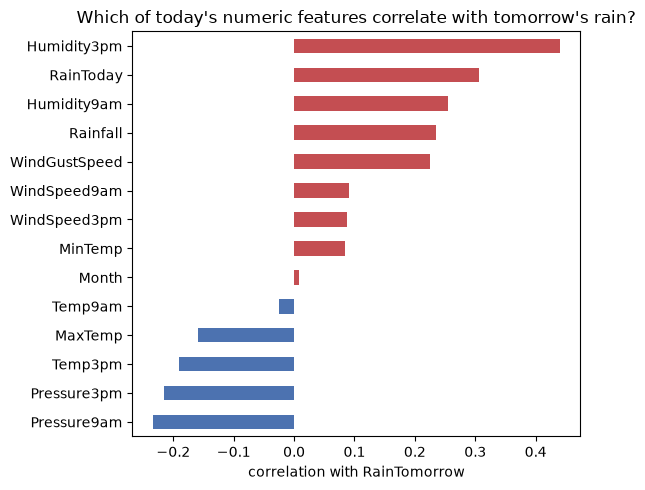

In [8]:
numeric_with_target = df[num_cols].copy()
numeric_with_target["RainTomorrow"] = target.values
corr = numeric_with_target.corr()["RainTomorrow"].drop("RainTomorrow").sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
corr.plot(kind="barh", ax=ax, color=["#C44E52" if v > 0 else "#4C72B0" for v in corr])
ax.set_xlabel("correlation with RainTomorrow")
ax.set_title("Which of today's numeric features correlate with tomorrow's rain?")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=120)
plt.show()

## 5. Train/test split and model

80/20 split, stratified on the target so both splits keep the same ~22%/78% rain/no-rain ratio.
`class_weight="balanced"` on the RandomForest, since a model optimizing plain accuracy on this
imbalanced a target tends to just predict "No" most of the time and still look accurate.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df_enc, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)
print(f"train: {X_train.shape}, test: {X_test.shape}")

clf = RandomForestClassifier(
    n_estimators=150, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
)
clf.fit(X_train, y_train)

train: (113754, 107), test: (28439, 107)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

## 6. Evaluate

In [10]:
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

print(f"accuracy:  {accuracy_score(y_test, pred):.3f}")
print(f"precision: {precision_score(y_test, pred):.3f}")
print(f"recall:    {recall_score(y_test, pred):.3f}")
print(f"f1:        {f1_score(y_test, pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, proba):.3f}")
print()
print(classification_report(y_test, pred, target_names=["No rain", "Rain"]))

accuracy:  0.814
precision: 0.565
recall:    0.741
f1:        0.641
ROC-AUC:   0.873

              precision    recall  f1-score   support

     No rain       0.92      0.84      0.87     22064
        Rain       0.57      0.74      0.64      6375

    accuracy                           0.81     28439
   macro avg       0.74      0.79      0.76     28439
weighted avg       0.84      0.81      0.82     28439



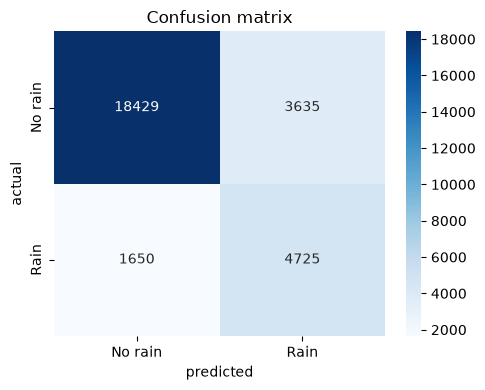

In [11]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No rain", "Rain"], yticklabels=["No rain", "Rain"], ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

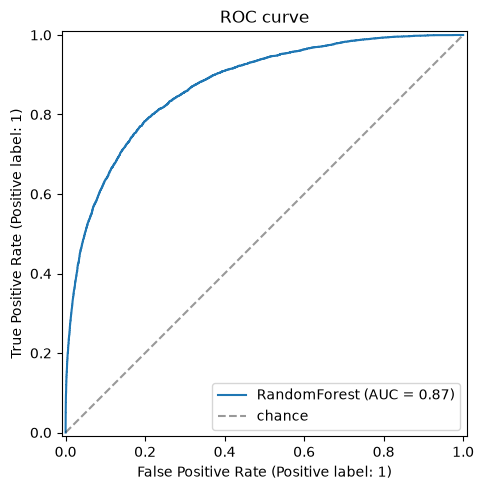

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name="RandomForest")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")
ax.set_title("ROC curve")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()

## 7. Feature importance

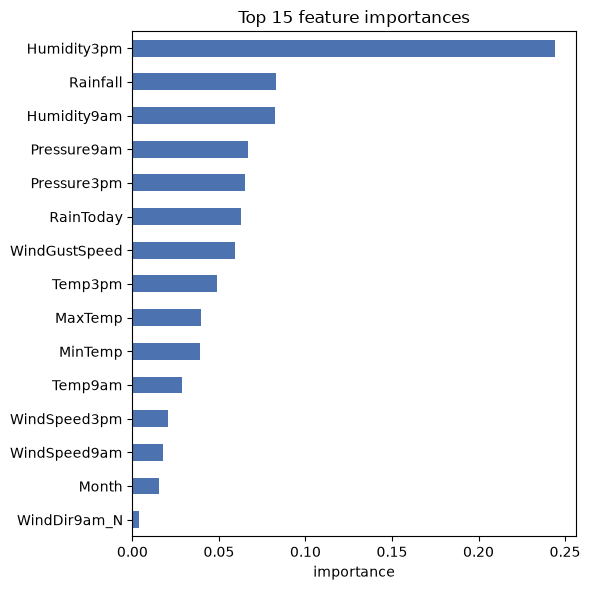

In [13]:
importances = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(6, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("importance")
ax.set_title("Top 15 feature importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

## Notes / limitations

- **Class imbalance**: only ~22% of days are followed by rain. `class_weight="balanced"` trades
  some precision for recall on the minority ("Rain") class -- for a rain forecast, missing an
  actual rainy day (false negative) is usually worse than an unnecessary umbrella (false
  positive), so this is a deliberate choice, not an oversight. Plain accuracy alone would be
  misleading here; that's why precision/recall/F1/ROC-AUC are all reported above, not just accuracy.
- **Random (not time-based) train/test split**: rows from the same station on nearby dates can
  end up on both sides of the split, which can inflate reported performance slightly versus a
  strict forecast-into-the-future evaluation (e.g. train on 2007-2015, test on 2016-2017). This
  matches how this dataset is conventionally split in most public benchmarks/tutorials, but is
  worth knowing if you're comparing this number to a genuinely time-blocked evaluation.
- **Missing-data columns dropped, not imputed**: `Sunshine`, `Evaporation`, `Cloud9am`,
  `Cloud3pm` were dropped rather than imputed because 35-48% of their values are missing --
  imputing that much would mean mostly inventing data rather than filling small gaps.